# ANIP - Tache 1 : Reconnaissance Faciale Robuste
## Face Matching/Verification - Version V4 Anti-Overfitting

**Correctifs V4 (basé sur analyse des courbes V3) :**
- EPOCHS Phase 1 : 14 → 5  (le modèle saturait dès l'époque 4)
- hard_ratio : 0.8 → 0.4  (mining trop agressif = mémorisation)
- MINING_K_CANDIDATES : 8 → 4  (réduire la difficulté initiale)
- Dropout : 0.3 → 0.5  (régularisation insuffisante)
- TRIPLET_MARGIN : 0.25 → 0.2  (marge plus douce = clusters plus stables)
- Augmentation renforcée : rotation ±15°, zoom ±10%, flou gaussien aléatoire
- EarlyStopping patience 4 → 3 pour phase 1 (5 epochs max de toute façon)
- Bug build_backbone tronqué en V3 : corrigé


## 1. Imports et Configuration V4


In [33]:
%matplotlib inline
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations
from collections import defaultdict
import cv2
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_v2_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
try:
    from tensorflow.keras.applications import ConvNeXtTiny
except ImportError:
    ConvNeXtTiny = None
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import (
    Dense, Lambda, GlobalAveragePooling2D, Dropout, BatchNormalization, Concatenate
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, classification_report

print('TensorFlow:', tf.__version__)
print('GPU disponible:', tf.config.list_physical_devices('GPU'))


TensorFlow: 2.21.0
GPU disponible: []


In [ ]:
# Chemins relatifs au notebook
NOTEBOOK_DIR = Path('.').resolve()
DATA_PATH = NOTEBOOK_DIR / 'anip-reconnaissance-faciale-estimation-ages-ocr' / 'dataset_tache_1' / 'dataset_tache_1'

# Fallback : chercher automatiquement
if not DATA_PATH.exists():
    candidates = list(NOTEBOOK_DIR.rglob('dataset_tache_1'))
    if candidates:
        DATA_PATH = candidates[-1]
        print(f'Dossier trouve : {DATA_PATH}')
    else:
        raise FileNotFoundError(f'Dossier dataset_tache_1 introuvable sous {NOTEBOOK_DIR}')

TRAIN_PATH = DATA_PATH / 'train'
TEST_PATH  = DATA_PATH / 'test'

IMG_SIZE   = (160, 160)
BATCH_SIZE = 32

# ── V4 : hyperparamètres corrigés ──────────────────────────────────────────
EPOCHS           =25    # était 14 — la val ne progresse plus après l'époque 4
FINE_TUNE_EPOCHS = 25  # inchangé
SEED             = 42
VAL_SIZE         = 0.2

BACKBONE         = 'mobilenetv2'
BACKBONE_WEIGHTS = 'imagenet'
EMBED_DIM        = 128
DROPOUT_RATE     = 0.5   # était 0.3 — insuffisant pour généraliser

TRIPLET_MARGIN       = 0.2    # était 0.25 — marge plus douce
TRAIN_TRIPLETS       = 8000
VAL_TRIPLETS         = 2000
MINING_K_CANDIDATES  = 4      # était 8 — moins de candidats hard
HARD_RATIO_TRAIN     = 0.4    # était 0.8 — curriculum plus progressif
HARD_RATIO_VAL       = 0.4    # était 0.7
TTA_FLIPS            = True

np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'Train : {TRAIN_PATH}')
print(f'Test  : {TEST_PATH}')
print(f'Backbone          : {BACKBONE}')
print(f'Dropout           : {DROPOUT_RATE}')
print(f'Triplet margin    : {TRIPLET_MARGIN}')
print(f'Hard ratio train  : {HARD_RATIO_TRAIN}')
print(f'MINING_K          : {MINING_K_CANDIDATES}')
print(f'Phase 1 epochs    : {EPOCHS}')


Train : C:\Users\Ibrahima\Documents\anip-age-estimation-kit\anip-reconnaissance-faciale-estimation-ages-ocr\dataset_tache_1\dataset_tache_1\train
Test  : C:\Users\Ibrahima\Documents\anip-age-estimation-kit\anip-reconnaissance-faciale-estimation-ages-ocr\dataset_tache_1\dataset_tache_1\test
Backbone          : mobilenetv2
Dropout           : 0.5
Triplet margin    : 0.2
Hard ratio train  : 0.4
MINING_K          : 4
Phase 1 epochs    : 5


## 2. Chargement et Analyse des Données

In [35]:
def parse_train_filename(filepath):
    """Format: XXXX_Y.jpg -> XXXX=person_id, Y=photo_num"""
    parts = filepath.stem.split('_')
    return int(parts[0]), int(parts[1])


def _list_valid_jpgs(folder):
    exts = {'.jpg', '.jpeg', '.JPG', '.JPEG'}
    files = []
    ignored_hidden = 0
    for p in folder.iterdir():
        if not p.is_file():
            continue
        if p.suffix not in exts:
            continue
        if p.name.startswith('._') or p.name.startswith('.'):
            ignored_hidden += 1
            continue
        files.append(p)
    return sorted(files), ignored_hidden


def load_train_data():
    """Charge les donnees d'entrainement en ignorant les artefacts macOS de type ._*."""
    train_images, ignored_hidden = _list_valid_jpgs(TRAIN_PATH)
    data = []
    ignored_invalid = 0
    for img_path in train_images:
        try:
            person_id, photo_num = parse_train_filename(img_path)
            data.append({'filepath': str(img_path), 'person_id': person_id, 'photo_num': photo_num})
        except (ValueError, IndexError):
            ignored_invalid += 1
    if ignored_hidden:
        print(f'Artefacts caches ignores : {ignored_hidden}')
    if ignored_invalid:
        print(f'Fichiers au nom invalide ignores : {ignored_invalid}')
    return pd.DataFrame(data).sort_values(['person_id', 'photo_num']).reset_index(drop=True)


print('Chargement des donnees...')
df_train = load_train_data()
print(f"Images chargees   : {len(df_train)}")
print(f"Personnes uniques : {df_train['person_id'].nunique()}")
print(df_train.groupby('person_id').size().describe())

person_ids = np.array(sorted(df_train['person_id'].unique()))
train_ids, val_ids = train_test_split(person_ids, test_size=VAL_SIZE, random_state=SEED)

df_train_split = df_train[df_train['person_id'].isin(train_ids)].reset_index(drop=True)
df_val_split   = df_train[df_train['person_id'].isin(val_ids)].reset_index(drop=True)

print()
print('Split par identite :')
print(f'  Train identities : {len(train_ids)} | images : {len(df_train_split)}')
print(f'  Val identities   : {len(val_ids)} | images : {len(df_val_split)}')
print(f'  Overlap IDs      : {len(set(train_ids) & set(val_ids))}')


Chargement des donnees...
Artefacts caches ignores : 3682
Images chargees   : 4000
Personnes uniques : 2000
count    2000.0
mean        2.0
std         0.0
min         2.0
25%         2.0
50%         2.0
75%         2.0
max         2.0
dtype: float64

Split par identite :
  Train identities : 1600 | images : 3200
  Val identities   : 400 | images : 800
  Overlap IDs      : 0


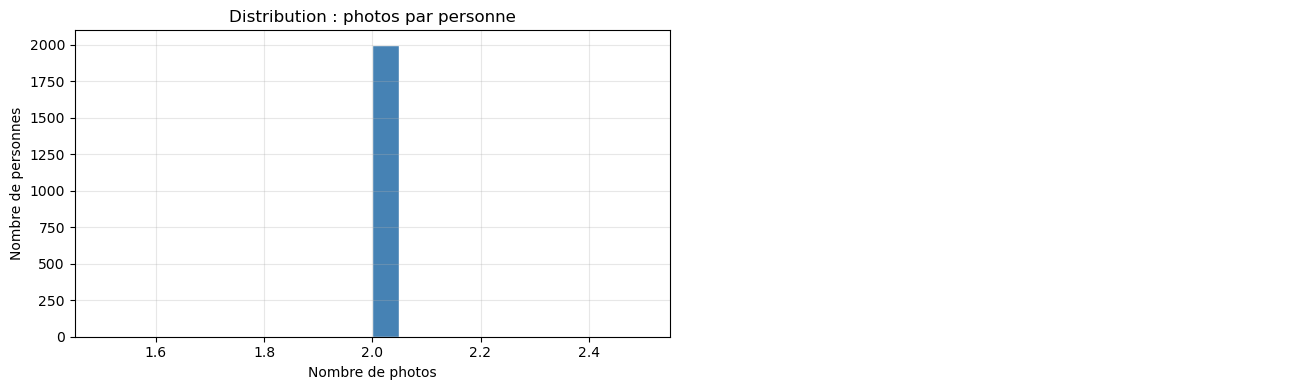

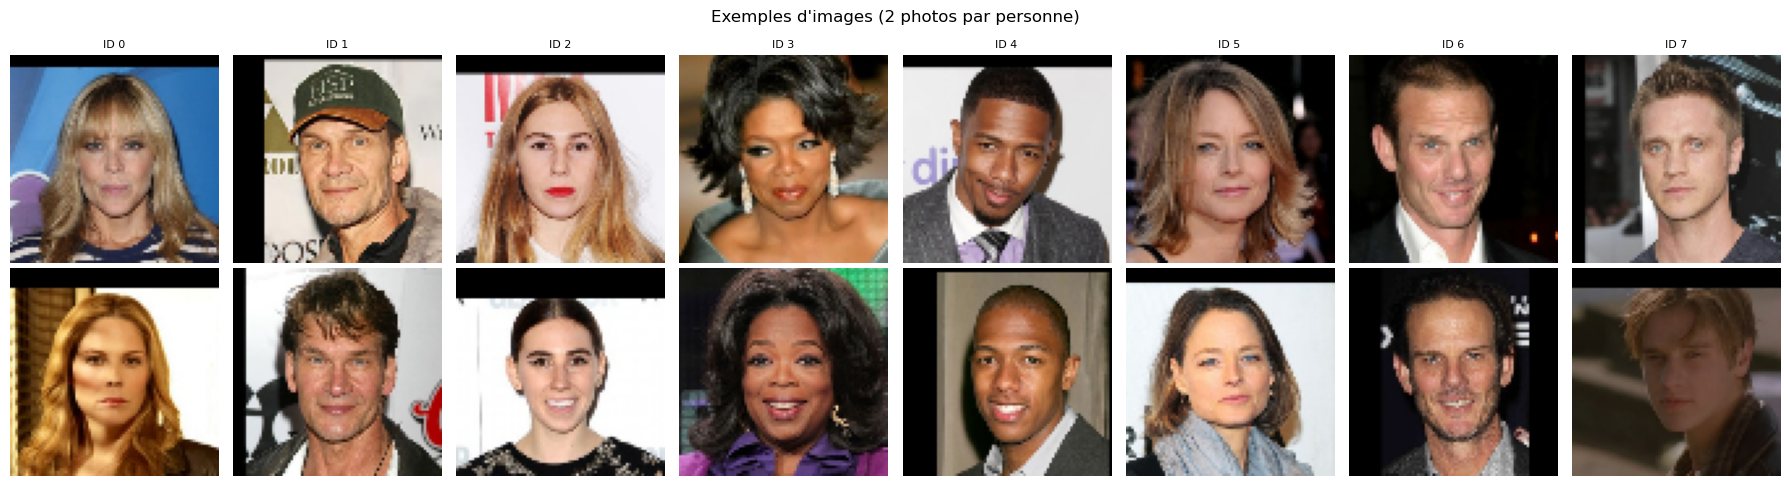

In [36]:
# Distribution du nombre de photos par personne
photos_per_person = df_train.groupby('person_id').size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(photos_per_person, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution : photos par personne')
axes[0].set_xlabel('Nombre de photos')
axes[0].set_ylabel('Nombre de personnes')
axes[0].grid(True, alpha=0.3)

# Afficher quelques images du dataset
sample = df_train.groupby('person_id').first().sample(8, random_state=SEED)
axes[1].axis('off')
plt.tight_layout()

fig2, axes2 = plt.subplots(2, 8, figsize=(18, 5))
sample_persons = df_train['person_id'].unique()[:8]
for col, pid in enumerate(sample_persons):
    person_imgs = df_train[df_train['person_id'] == pid]['filepath'].values
    for row, img_path in enumerate(person_imgs[:2]):
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (80, 80))
            axes2[row, col].imshow(img)
        axes2[row, col].axis('off')
        if row == 0:
            axes2[row, col].set_title(f'ID {pid}', fontsize=8)

fig2.suptitle('Exemples d\'images (2 photos par personne)', fontsize=12)
plt.tight_layout()
plt.show()


## 3. Creation des Triplets et Hard Negative Mining


In [37]:
def get_backbone_preprocess(backbone_name):
    if backbone_name == 'mobilenetv2':
        return mobilenet_v2_preprocess
    if backbone_name == 'efficientnetb0':
        return efficientnet_preprocess
    if backbone_name == 'convnext_tiny':
        return lambda x: x
    raise ValueError(f'Backbone non supporte : {backbone_name}')


BACKBONE_PREPROCESS = get_backbone_preprocess(BACKBONE)


def load_and_preprocess_image(image_path, img_size=IMG_SIZE, augment=False, flip=False):
    """
    Charge et pretraite une image.
    V4 : augmentation renforcée (rotation, zoom, flou gaussien).
    """
    try:
        img = cv2.imread(str(image_path))
        if img is None:
            raise ValueError(f'Impossible de lire : {image_path}')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, img_size)
        img = img.astype('float32')

        if augment:
            h, w = img.shape[:2]

            # Flip horizontal
            if np.random.rand() > 0.5:
                img = img[:, ::-1, :]

            # Rotation aléatoire ±15°
            angle = np.random.uniform(-15.0, 15.0)
        #   M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
            M = cv2.getRotationMatrix2D((img_size[0]//2, img_size[1]//2), angle, 1.0)
        #  img = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR,
        #                      borderMode=cv2.BORDER_REFLECT_101)
            img = cv2.warpAffine(img, M, img_size)

            # Zoom aléatoire ±10%
            scale = np.random.uniform(0.90, 1.10)
            M_zoom = cv2.getRotationMatrix2D((w / 2, h / 2), 0, scale)
            img = cv2.warpAffine(img, M_zoom, (w, h), flags=cv2.INTER_LINEAR,
                                 borderMode=cv2.BORDER_REFLECT_101)

            # Luminosité + contraste
            delta = np.random.uniform(-25, 25)
            img = np.clip(img + delta, 0.0, 255.0)
            factor = np.random.uniform(0.85, 1.15)
            mean = img.mean(axis=(0, 1), keepdims=True)
            img = np.clip((img - mean) * factor + mean, 0.0, 255.0)

            # Flou gaussien aléatoire (50% du temps)
            if np.random.rand() > 0.8:
                ksize = np.random.choice([3, 5])
                img = cv2.GaussianBlur(img, (ksize, ksize), 0)

        if flip:
            img = img[:, ::-1, :]

        img = BACKBONE_PREPROCESS(img)
        return img.astype('float32')
    except Exception as e:
        print(f'  [WARN] Image ignoree : {e}')
        return np.zeros((*img_size, 3), dtype='float32')


# ── Build backbone (complet — corrige la troncature de V3) ──────────────────

def _load_model_with_fallback(builder, backbone_name, input_shape, fine_tune_last_n):
    requested_weights = BACKBONE_WEIGHTS
    try:
        model = builder(include_top=False, weights=requested_weights, input_shape=input_shape)
        print(f'{backbone_name}: poids charges = {requested_weights}')
    except Exception as e:
        print(f'[WARN] {backbone_name}: impossible de charger {requested_weights} ({e})')
        print(f'[WARN] {backbone_name}: fallback weights=None')
        model = builder(include_top=False, weights=None, input_shape=input_shape)
    return model, fine_tune_last_n


def build_backbone(backbone_name, input_shape):
    if backbone_name == 'mobilenetv2':
        model, ftn = _load_model_with_fallback(MobileNetV2, 'mobilenetv2', input_shape, 30)
        model._name = 'mobilenetv2_backbone'
    elif backbone_name == 'efficientnetb0':
        model, ftn = _load_model_with_fallback(EfficientNetB0, 'efficientnetb0', input_shape, 40)
        model._name = 'efficientnetb0_backbone'
    elif backbone_name == 'convnext_tiny':
        if ConvNeXtTiny is None:
            raise ImportError('ConvNeXtTiny indisponible — repasse a mobilenetv2.')
        model, ftn = _load_model_with_fallback(ConvNeXtTiny, 'convnext_tiny', input_shape, 20)
        model._name = 'convnext_tiny_backbone'
    else:
        raise ValueError(f'Backbone non supporte : {backbone_name}')
    return model, model.name, ftn


# ── Hard Negative Mining ─────────────────────────────────────────────────────

def build_identity_index(df):
    grouped = {}
    for pid, grp in df.groupby('person_id'):
        files = grp['filepath'].tolist()
        if len(files) >= 2:
            grouped[pid] = files
    return grouped


def build_mining_encoder(backbone_name, input_shape):
    backbone_model, _, _ = build_backbone(backbone_name, input_shape)
    backbone_model.trainable = False
    inputs = Input(shape=input_shape)
    x = backbone_model(inputs, training=False)
    x = GlobalAveragePooling2D(name='miner_gap')(x)
    outputs = Lambda(lambda t: tf.math.l2_normalize(t, axis=1), name='miner_l2')(x)
    return Model(inputs, outputs, name='mining_encoder')


def get_identity_prototypes(df, encoder, batch_size=32):
    prototype_rows = (df.sort_values(['person_id', 'photo_num'])
                       .groupby('person_id').head(1)
                       .reset_index(drop=True))
    filepaths = prototype_rows['filepath'].tolist()
    feats = []
    for start in tqdm(range(0, len(filepaths), batch_size), desc='Mining prototypes'):
        batch_paths = filepaths[start:start + batch_size]
        imgs = np.array([load_and_preprocess_image(p, augment=False) for p in batch_paths], dtype='float32')
        feats.append(encoder.predict(imgs, verbose=0))
    feats = np.vstack(feats)
    ids = prototype_rows['person_id'].tolist()
    return {pid: emb for pid, emb in zip(ids, feats)}


def compute_hard_negative_map(identity_to_proto, k=MINING_K_CANDIDATES):
    ids = list(identity_to_proto.keys())
    mat = np.stack([identity_to_proto[pid] for pid in ids], axis=0)
    sims = mat @ mat.T
    np.fill_diagonal(sims, -1.0)
    hard_map = {}
    for idx, pid in enumerate(ids):
        order = np.argsort(-sims[idx])
        hard_ids = [ids[j] for j in order[:k] if sims[idx, j] > -0.5]
        hard_map[pid] = hard_ids
    return hard_map


def create_triplets(df, n_triplets=4000, seed=SEED,
                    hard_negative_map=None, hard_ratio=0.4):
    rng = np.random.default_rng(seed)
    identity_index = build_identity_index(df)
    person_ids = np.array(sorted(identity_index.keys()))
    triplets = []
    for _ in range(n_triplets):
        anchor_id = int(rng.choice(person_ids))
        pos_candidates = identity_index[anchor_id]
        anchor_path, positive_path = rng.choice(pos_candidates, size=2, replace=False)
        use_hard = (
            hard_negative_map is not None
            and anchor_id in hard_negative_map
            and len(hard_negative_map[anchor_id]) > 0
            and rng.random() < hard_ratio
        )
        if use_hard:
            negative_id = int(rng.choice(hard_negative_map[anchor_id]))
        else:
            negative_pool = person_ids[person_ids != anchor_id]
            negative_id = int(rng.choice(negative_pool))
        negative_path = str(rng.choice(identity_index[negative_id]))
        triplets.append([anchor_path, positive_path, negative_path])
    return np.array(triplets, dtype=object)


identity_index_train = build_identity_index(df_train_split)
identity_index_val   = build_identity_index(df_val_split)
print(f'Identites train (>=2 photos) : {len(identity_index_train)}')
print(f'Identites val   (>=2 photos) : {len(identity_index_val)}')

input_shape = (IMG_SIZE[0], IMG_SIZE[1], 3)
mining_encoder = build_mining_encoder(BACKBONE, input_shape)

train_prototypes      = get_identity_prototypes(df_train_split, mining_encoder, BATCH_SIZE)
val_prototypes        = get_identity_prototypes(df_val_split,   mining_encoder, BATCH_SIZE)

hard_negative_map_train = compute_hard_negative_map(train_prototypes, k=MINING_K_CANDIDATES)
hard_negative_map_val   = compute_hard_negative_map(val_prototypes,   k=max(2, MINING_K_CANDIDATES // 2))

# V4 : hard_ratio réduit de 0.8 → HARD_RATIO_TRAIN
triplets_train = create_triplets(
    df_train_split,
    n_triplets=TRAIN_TRIPLETS,
    seed=SEED,
    hard_negative_map=hard_negative_map_train,
    hard_ratio=HARD_RATIO_TRAIN,
)
triplets_val = create_triplets(
    df_val_split,
    n_triplets=VAL_TRIPLETS,
    seed=SEED + 1,
    hard_negative_map=hard_negative_map_val,
    hard_ratio=HARD_RATIO_VAL,
)

print()
print(f'Train triplets : {len(triplets_train)}')
print(f'Val triplets   : {len(triplets_val)}')
print('Exemple triplet :')
print(triplets_train[0])


Identites train (>=2 photos) : 1600
Identites val   (>=2 photos) : 400
mobilenetv2: poids charges = imagenet


Mining prototypes: 100%|██████████| 13/13 [00:01<00:00,  7.87it/s]



Train triplets : 8000
Val triplets   : 2000
Exemple triplet :
[np.str_('C:\\Users\\Ibrahima\\Documents\\anip-age-estimation-kit\\anip-reconnaissance-faciale-estimation-ages-ocr\\dataset_tache_1\\dataset_tache_1\\train\\0172_0.jpg')
 np.str_('C:\\Users\\Ibrahima\\Documents\\anip-age-estimation-kit\\anip-reconnaissance-faciale-estimation-ages-ocr\\dataset_tache_1\\dataset_tache_1\\train\\0172_1.jpg')
 'C:\\Users\\Ibrahima\\Documents\\anip-age-estimation-kit\\anip-reconnaissance-faciale-estimation-ages-ocr\\dataset_tache_1\\dataset_tache_1\\train\\0878_0.jpg']


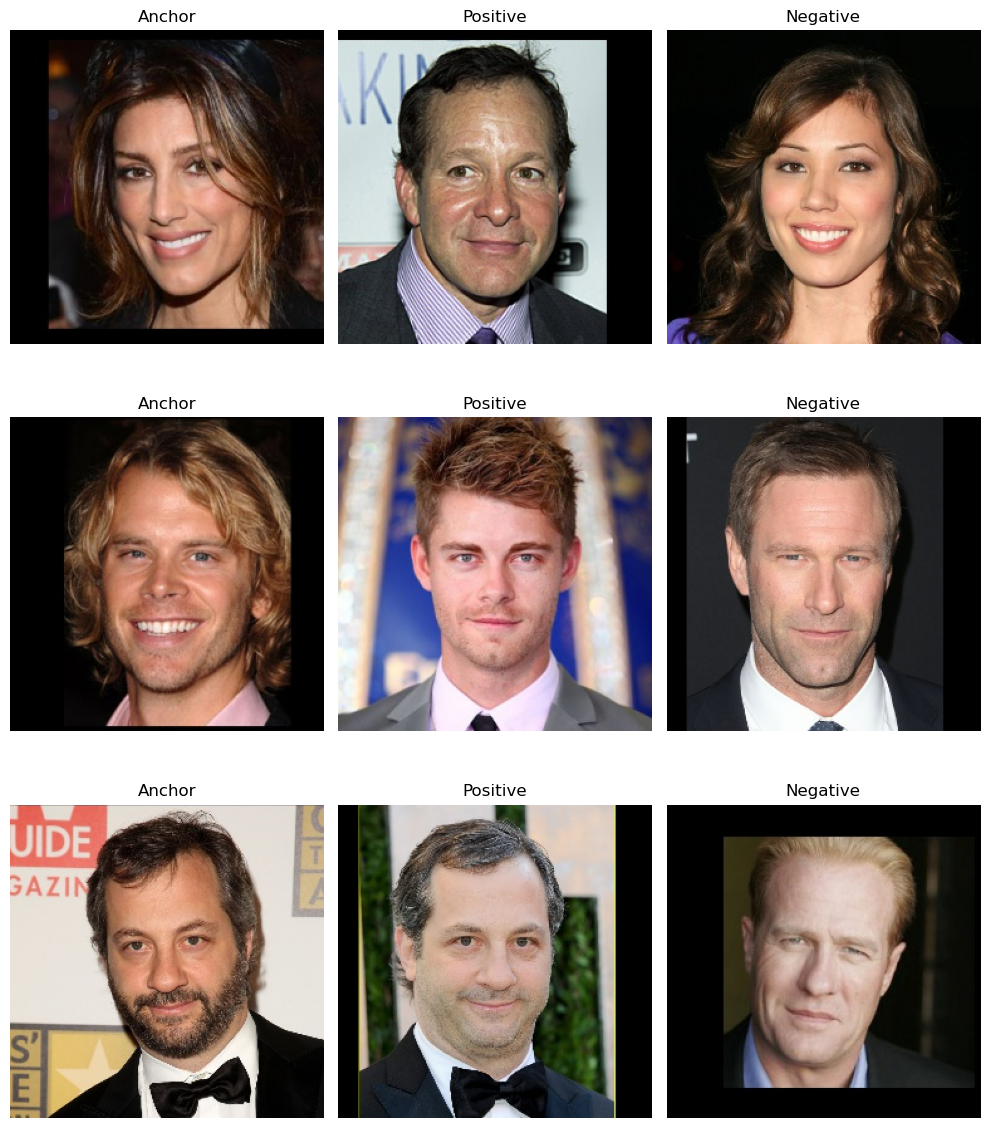

In [38]:
# Visualiser quelques triplets (anchor / positive / negative)
sample_triplets = triplets_train[np.random.choice(len(triplets_train), size=min(3, len(triplets_train)), replace=False)]
fig, axes = plt.subplots(len(sample_triplets), 3, figsize=(10, 4 * len(sample_triplets)))
if len(sample_triplets) == 1:
    axes = np.expand_dims(axes, axis=0)

titles = ['Anchor', 'Positive', 'Negative']
for row_idx, triplet in enumerate(sample_triplets):
    for col_idx, img_path in enumerate(triplet):
        img = cv2.imread(str(img_path))
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].set_title(titles[col_idx])
        axes[row_idx, col_idx].axis('off')
plt.tight_layout()
plt.show()


## 4. Generateur de Donnees Triplet + Augmentation


In [39]:
def triplet_generator(triplets, batch_size=32, shuffle=True, augment=False):
    n = len(triplets)
    indices = np.arange(n)
    dummy = np.zeros((batch_size,), dtype='float32')
    while True:
        if shuffle:
            np.random.shuffle(indices)
        for start in range(0, n, batch_size):
            batch_idx = indices[start:start + batch_size]
            batch_triplets = triplets[batch_idx]
            anchors = np.array([load_and_preprocess_image(t[0], augment=augment) for t in batch_triplets], dtype='float32')
            positives = np.array([load_and_preprocess_image(t[1], augment=augment) for t in batch_triplets], dtype='float32')
            negatives = np.array([load_and_preprocess_image(t[2], augment=augment) for t in batch_triplets], dtype='float32')
            yield (anchors, positives, negatives), dummy[:len(batch_idx)]


## 5. Architecture Metric Learning (Triplet Loss)


In [40]:
def create_base_network(input_shape):
    """Backbone ImageNet + tete d'embedding L2-normalisee. V4 : Dropout configurable."""
    backbone_model, backbone_name, fine_tune_last_n = build_backbone(BACKBONE, input_shape)
    backbone_model.trainable = False

    inputs = Input(shape=input_shape)
    x = backbone_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(DROPOUT_RATE)(x)          # V4 : 0.5 au lieu de 0.3
    x = Dense(EMBED_DIM, activation='linear')(x)
    embeddings = Lambda(lambda t: tf.math.l2_normalize(t, axis=1), name='l2_norm')(x)

    model = Model(inputs=inputs, outputs=embeddings, name='base_network')
    return model, backbone_name, fine_tune_last_n


def triplet_loss_fn(y_true, y_pred, margin=TRIPLET_MARGIN):
    anchor   = y_pred[:, :EMBED_DIM]
    positive = y_pred[:, EMBED_DIM:2 * EMBED_DIM]
    negative = y_pred[:, 2 * EMBED_DIM:]
    pos_dist = tf.reduce_sum(tf.square(anchor - positive), axis=1)
    neg_dist = tf.reduce_sum(tf.square(anchor - negative), axis=1)
    losses   = tf.maximum(pos_dist - neg_dist + margin, 0.0)
    return tf.reduce_mean(losses)


def triplet_accuracy(y_true, y_pred):
    anchor   = y_pred[:, :EMBED_DIM]
    positive = y_pred[:, EMBED_DIM:2 * EMBED_DIM]
    negative = y_pred[:, 2 * EMBED_DIM:]
    pos_sim  = tf.reduce_sum(anchor * positive, axis=1)
    neg_sim  = tf.reduce_sum(anchor * negative, axis=1)
    return tf.reduce_mean(tf.cast(pos_sim > neg_sim, tf.float32))


def create_triplet_model(input_shape):
    base_network, backbone_name, fine_tune_last_n = create_base_network(input_shape)

    anchor_in   = Input(shape=input_shape, name='anchor_input')
    positive_in = Input(shape=input_shape, name='positive_input')
    negative_in = Input(shape=input_shape, name='negative_input')

    anchor_emb   = base_network(anchor_in)
    positive_emb = base_network(positive_in)
    negative_emb = base_network(negative_in)

    merged = Concatenate(name='triplet_embeddings')([anchor_emb, positive_emb, negative_emb])
    triplet_model = Model(
        inputs=[anchor_in, positive_in, negative_in],
        outputs=merged,
        name='triplet_network',
    )
    return triplet_model, base_network, backbone_name, fine_tune_last_n


triplet_model, base_network, backbone_layer_name, fine_tune_last_n = create_triplet_model(input_shape)

triplet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=triplet_loss_fn,
    metrics=[triplet_accuracy],
)
triplet_model.summary()
print(f'Backbone actif : {backbone_layer_name} | fine-tune last n = {fine_tune_last_n}')
print(f'Dropout        : {DROPOUT_RATE}')
print(f'Triplet margin : {TRIPLET_MARGIN}')


mobilenetv2: poids charges = imagenet


Model: "triplet_network"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ anchor_input        │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positive_input      │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative_input      │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ base_network        │ (None, 128)       │  2,619,840 │ anchor_input[0][… │
│ (Functional)        │                   │            │ positive_input[0… │
│                     │                   │            │ negative_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ triplet_embeddings  │ (None, 384)       │          0 │ base_network[0][… │
│ (Concatenate)       │                   │            │ base_network[1][… │
│                     │                   │            │ base_network[2][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,619,840 (9.99 MB)

 Trainable params: 361,344 (1.38 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

Backbone actif : mobilenetv2_1.00_160 | fine-tune last n = 30
Dropout        : 0.5
Triplet margin : 0.2


## 6. Entrainement - Phase 1 (Feature Extraction avec Triplets)


In [ ]:
steps_per_epoch  = max(1, int(np.ceil(len(triplets_train) / BATCH_SIZE)))
validation_steps = max(1, int(np.ceil(len(triplets_val)   / BATCH_SIZE)))

train_gen = triplet_generator(triplets_train, BATCH_SIZE, shuffle=True,  augment=True)
val_gen   = triplet_generator(triplets_val,   BATCH_SIZE, shuffle=False, augment=False)

callbacks_phase1 = [
    keras.callbacks.ModelCheckpoint(
        'best_triplet_phase1.keras',
        monitor='val_triplet_accuracy', save_best_only=True, mode='max', verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_triplet_accuracy',
        patience=3,                      # V4 : 3 au lieu de 4 (cohérent avec EPOCHS=5)
        restore_best_weights=True,
        verbose=1, mode='max',
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1,
    ),
]

print(f'Phase 1 : feature extraction ({BACKBONE} gele) avec triplet loss...')
print(f'  EPOCHS={EPOCHS} | hard_ratio={HARD_RATIO_TRAIN} | dropout={DROPOUT_RATE}')
history1 = triplet_model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
    epochs=EPOCHS,
    callbacks=callbacks_phase1,
    verbose=1,
)
print('Phase 1 terminee!')


Phase 1 : feature extraction (mobilenetv2 gele) avec triplet loss...
  EPOCHS=5 | hard_ratio=0.4 | dropout=0.5
Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - loss: 0.2481 - triplet_accuracy: 0.5208
Epoch 1: val_triplet_accuracy improved from None to 0.52778, saving model to best_triplet_phase1.keras

Epoch 1: finished saving model to best_triplet_phase1.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 74s 275ms/step - loss: 0.2468 - triplet_accuracy: 0.5271 - val_loss: 0.2826 - val_triplet_accuracy: 0.5278 - learning_rate: 1.0000e-04
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - loss: 0.2353 - triplet_accuracy: 0.5375
Epoch 2: val_triplet_accuracy did not improve from 0.52778
250/250 ━━━━━━━━━━━━━━━━━━━━ 66s 263ms/step - loss: 0.2334 - triplet_accuracy: 0.5419 - val_loss: 0.2861 - val_triplet_accuracy: 0.5253 - learning_rate: 1.0000e-04
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - loss: 0.2256 - triplet_accuracy: 0.5546

## 7. Fine-Tuning - Phase 2 (Dernieres Couches du Backbone)


In [ ]:
# Degeler uniquement les dernieres couches du backbone choisi
backbone_model = base_network.get_layer(backbone_layer_name)
backbone_model.trainable = True

if fine_tune_last_n > 0:
    for layer in backbone_model.layers[:-fine_tune_last_n]:
        layer.trainable = False

trainable_count = sum(1 for l in backbone_model.layers if l.trainable)
print(f'Couches entrainables dans {BACKBONE} : {trainable_count}')

triplet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=triplet_loss_fn,
    metrics=[triplet_accuracy],
)

train_gen2 = triplet_generator(triplets_train, BATCH_SIZE, shuffle=True, augment=True)
val_gen2 = triplet_generator(triplets_val, BATCH_SIZE, shuffle=False, augment=False)

callbacks_phase2 = [
    keras.callbacks.ModelCheckpoint(
        'best_triplet_final.keras',
        monitor='val_triplet_accuracy', save_best_only=True, mode='max', verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_triplet_accuracy', patience=6 restore_best_weights=True, verbose=1, mode='max'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, min_lr=1e-8, verbose=1
    ),
]

print('Phase 2 : fine-tuning metric learning...')
history2 = triplet_model.fit(
    train_gen2,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen2,
    validation_steps=validation_steps,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks_phase2,
    verbose=1,
)
print('Fine-tuning termine!')


Couches entrainables dans mobilenetv2 : 30
Phase 2 : fine-tuning metric learning...
Epoch 1/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - loss: 0.2354 - triplet_accuracy: 0.5343
Epoch 1: val_triplet_accuracy improved from None to 0.54167, saving model to best_triplet_final.keras

Epoch 1: finished saving model to best_triplet_final.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 81s 293ms/step - loss: 0.2336 - triplet_accuracy: 0.5381 - val_loss: 0.2707 - val_triplet_accuracy: 0.5417 - learning_rate: 1.0000e-05
Epoch 2/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - loss: 0.2272 - triplet_accuracy: 0.5469
Epoch 2: val_triplet_accuracy improved from 0.54167 to 0.55754, saving model to best_triplet_final.keras

Epoch 2: finished saving model to best_triplet_final.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 70s 280ms/step - loss: 0.2295 - triplet_accuracy: 0.5424 - val_loss: 0.2517 - val_triplet_accuracy: 0.5575 - learning_rate: 1.0000e-05
Epoch 3/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - loss: 0.2298 - t

## 8. Courbes d'Entrainement


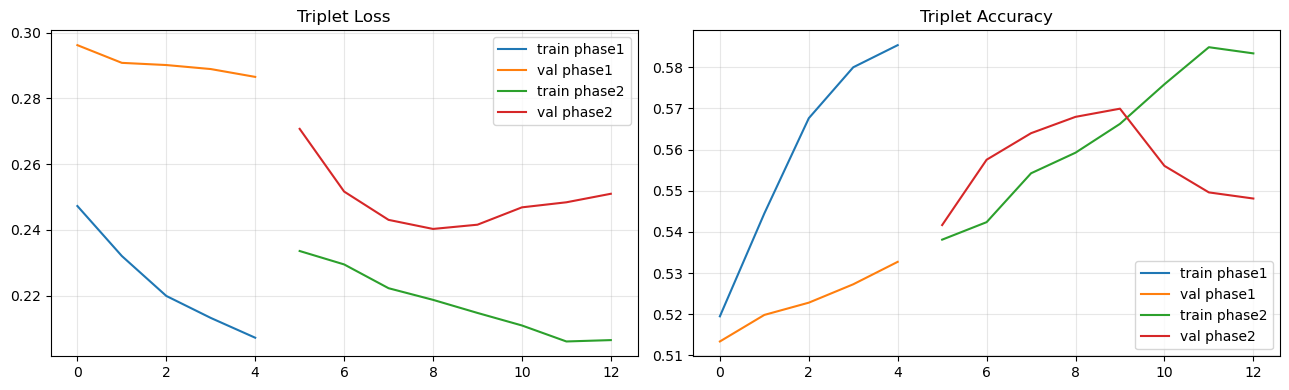

In [ ]:
def plot_history(h1, h2=None):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(h1.history['loss'], label='train phase1')
    axes[0].plot(h1.history['val_loss'], label='val phase1')
    if h2 is not None:
        axes[0].plot(range(len(h1.history['loss']), len(h1.history['loss']) + len(h2.history['loss'])), h2.history['loss'], label='train phase2')
        axes[0].plot(range(len(h1.history['val_loss']), len(h1.history['val_loss']) + len(h2.history['val_loss'])), h2.history['val_loss'], label='val phase2')
    axes[0].set_title('Triplet Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(h1.history['triplet_accuracy'], label='train phase1')
    axes[1].plot(h1.history['val_triplet_accuracy'], label='val phase1')
    if h2 is not None:
        axes[1].plot(range(len(h1.history['triplet_accuracy']), len(h1.history['triplet_accuracy']) + len(h2.history['triplet_accuracy'])), h2.history['triplet_accuracy'], label='train phase2')
        axes[1].plot(range(len(h1.history['val_triplet_accuracy']), len(h1.history['val_triplet_accuracy']) + len(h2.history['val_triplet_accuracy'])), h2.history['val_triplet_accuracy'], label='val phase2')
    axes[1].set_title('Triplet Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_history(history1, history2)


## 9. Extraction d'Embeddings + TTA


In [ ]:

def create_pairs(df, n_positive=2000, n_negative=2000, seed=SEED):
    rng = np.random.default_rng(seed)
    pairs, labels = [], []
    seen = set()

    person_groups = {
        pid: grp['filepath'].values
        for pid, grp in df.groupby('person_id')
        if len(grp) >= 2
    }
    person_ids = np.array(list(person_groups.keys()))

    positive_candidates = []
    for pid, imgs in person_groups.items():
        for img_a, img_b in combinations(imgs, 2):
            positive_candidates.append((img_a, img_b, pid))

    rng.shuffle(positive_candidates)
    max_positive = len(positive_candidates) if n_positive is None else min(n_positive, len(positive_candidates))
    for img_a, img_b, pid in positive_candidates[:max_positive]:
        key = tuple(sorted((img_a, img_b)))
        seen.add(key)
        pairs.append([img_a, img_b])
        labels.append(1)

    if n_negative is None:
        n_negative = len(labels)

    attempts = 0
    negative_target = int(n_negative)
    while sum(1 for l in labels if l == 0) < negative_target and attempts < negative_target * 30:
        attempts += 1
        pid1, pid2 = rng.choice(person_ids, 2, replace=False)
        img1 = rng.choice(person_groups[pid1])
        img2 = rng.choice(person_groups[pid2])
        key = tuple(sorted((img1, img2)))
        if key not in seen:
            seen.add(key)
            pairs.append([img1, img2])
            labels.append(0)

    return np.array(pairs), np.array(labels)


def get_embeddings(filepaths, base_network, batch_size=32, use_tta=False):
    embeddings = []
    for i in tqdm(range(0, len(filepaths), batch_size), desc='Embeddings'):
        batch = filepaths[i:i + batch_size]
        imgs = np.array([load_and_preprocess_image(p, augment=False, flip=False) for p in batch], dtype='float32')
        embs = base_network.predict(imgs, verbose=0)

        if use_tta and TTA_FLIPS:
            imgs_flip = np.array([load_and_preprocess_image(p, augment=False, flip=True) for p in batch], dtype='float32')
            embs_flip = base_network.predict(imgs_flip, verbose=0)
            embs = embs + embs_flip
            embs = embs / np.linalg.norm(embs, axis=1, keepdims=True).clip(min=1e-8)

        embeddings.extend(embs)
    return np.array(embeddings)


val_embeddings = get_embeddings(df_val_split['filepath'].values, base_network, use_tta=True)
df_val_embeddings = df_val_split.copy()
df_val_embeddings['embedding'] = list(val_embeddings)
print(f'Embeddings validation shape : {val_embeddings.shape}')


Embeddings: 100%|██████████| 25/25 [00:05<00:00,  4.80it/s]

Embeddings validation shape : (800, 128)


## 10. Calibration du Seuil par Courbe ROC


AUC-ROC       : 0.5940
Seuil optimal : 0.0328  (TPR=0.640, FPR=0.492)


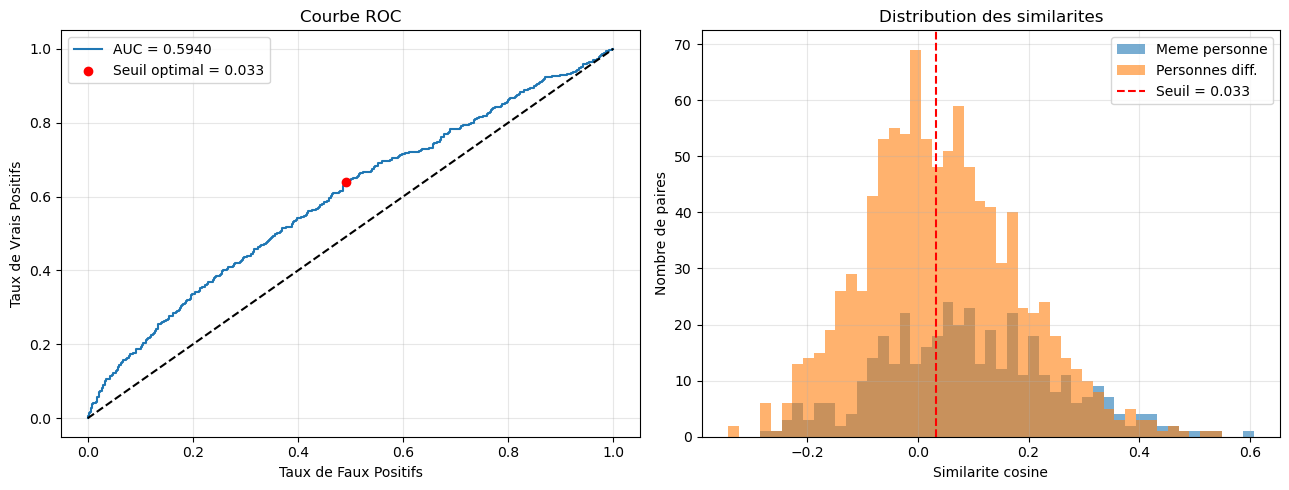


Classification Report (validation) :
              precision    recall  f1-score   support

       Diff.       0.78      0.51      0.62      1000
        Meme       0.34      0.64      0.45       400

    accuracy                           0.55      1400
   macro avg       0.56      0.57      0.53      1400
weighted avg       0.65      0.55      0.57      1400



In [ ]:
# Construire des paires d'evaluation a partir des memes splits
pairs_val, labels_val = create_pairs(
    df_val_split,
    n_positive=1000,
    n_negative=1000,
    seed=SEED + 123,
)

emb_dict = dict(zip(df_val_embeddings['filepath'].values, val_embeddings))

valid_mask = np.array([
    (p[0] in emb_dict) and (p[1] in emb_dict)
    for p in pairs_val
])
pairs_val_eval = pairs_val[valid_mask]
labels_val_eval = labels_val[valid_mask]

val_sims = np.array([
    float(np.dot(emb_dict[p[0]], emb_dict[p[1]]))
    for p in pairs_val_eval
])

fpr, tpr, thresholds = roc_curve(labels_val_eval, val_sims)
roc_auc = auc(fpr, tpr)

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = float(thresholds[optimal_idx])

print(f'AUC-ROC       : {roc_auc:.4f}')
print(f'Seuil optimal : {optimal_threshold:.4f}  (TPR={tpr[optimal_idx]:.3f}, FPR={fpr[optimal_idx]:.3f})')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
ax1.scatter(
    fpr[optimal_idx],
    tpr[optimal_idx],
    color='red',
    zorder=5,
    label=f'Seuil optimal = {optimal_threshold:.3f}',
)
ax1.plot([0, 1], [0, 1], 'k--')
ax1.set_xlabel('Taux de Faux Positifs')
ax1.set_ylabel('Taux de Vrais Positifs')
ax1.set_title('Courbe ROC')
ax1.legend()
ax1.grid(True, alpha=0.3)

bins = np.linspace(val_sims.min(), val_sims.max(), 50)
ax2.hist(val_sims[labels_val_eval == 1], bins=bins, alpha=0.6, label='Meme personne')
ax2.hist(val_sims[labels_val_eval == 0], bins=bins, alpha=0.6, label='Personnes diff.')
ax2.axvline(optimal_threshold, color='red', linestyle='--', label=f'Seuil = {optimal_threshold:.3f}')
ax2.set_xlabel('Similarite cosine')
ax2.set_ylabel('Nombre de paires')
ax2.set_title('Distribution des similarites')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curve_v3.png', dpi=150, bbox_inches='tight')
plt.show()

val_preds = (val_sims >= optimal_threshold).astype(int)
print('\nClassification Report (validation) :')
print(classification_report(labels_val_eval, val_preds, target_names=['Diff.', 'Meme'], zero_division=0))


## 11. Prediction sur le Test Set


In [ ]:
def predict_test_set(test_path, base_network, threshold, use_tta=True):
    test_images, ignored_hidden = _list_valid_jpgs(test_path)
    print(f'Images de test : {len(test_images)}')
    if ignored_hidden:
        print(f'Artefacts caches ignores dans le test : {ignored_hidden}')

    df_test = pd.DataFrame({
        'filepath': [str(p) for p in test_images],
        'filename': [p.name for p in test_images],
    })
    test_embs = get_embeddings(df_test['filepath'].values, base_network, use_tta=use_tta)
    df_test['embedding'] = list(test_embs)

    sim_matrix = test_embs @ test_embs.T

    matches = []
    n = len(df_test)
    for i in range(n):
        for j in range(i + 1, n):
            sim = float(sim_matrix[i, j])
            if sim >= threshold:
                matches.append({
                    'image1': df_test.iloc[i]['filename'],
                    'image2': df_test.iloc[j]['filename'],
                    'similarity': round(sim, 5),
                    'is_match': 1,
                })
    return pd.DataFrame(matches), df_test


matches_df, df_test = predict_test_set(TEST_PATH, base_network, threshold=optimal_threshold, use_tta=True)
print(f'Paires matchees : {len(matches_df)}')
print(matches_df.head(10))


Images de test : 2000


Embeddings: 100%|██████████| 63/63 [00:12<00:00,  5.13it/s]


Paires matchees : 1030085
       image1      image2  similarity  is_match
0  3000_0.jpg  3001_1.jpg     0.15801         1
1  3000_0.jpg  3002_0.jpg     0.06581         1
2  3000_0.jpg  3002_1.jpg     0.10358         1
3  3000_0.jpg  3003_0.jpg     0.13024         1
4  3000_0.jpg  3003_1.jpg     0.04651         1
5  3000_0.jpg  3004_0.jpg     0.13490         1
6  3000_0.jpg  3005_1.jpg     0.15592         1
7  3000_0.jpg  3006_0.jpg     0.15265         1
8  3000_0.jpg  3006_1.jpg     0.05979         1
9  3000_0.jpg  3007_1.jpg     0.42121         1


## 12. Fichier de Soumission


In [ ]:
matches_df.to_csv('tache1_submission_v4.csv', index=False)
print('Soumission sauvegardee : tache1_submission_v4.csv')
print(f'Seuil utilise   : {optimal_threshold:.4f}')
print(f'AUC-ROC         : {roc_auc:.4f}')
print(f'Backbone        : {BACKBONE}')
print(f'TTA             : {TTA_FLIPS}')
print(f'Margin          : {TRIPLET_MARGIN}')
print(f'Hard ratio      : {HARD_RATIO_TRAIN}')
print(f'Dropout         : {DROPOUT_RATE}')


Soumission sauvegardee : tache1_submission_v4.csv
Seuil utilise   : 0.0328
AUC-ROC         : 0.5940
Backbone        : mobilenetv2
TTA             : True
Margin          : 0.2
Hard ratio      : 0.4
Dropout         : 0.5


## 13. Visualisation des Paires Matchees


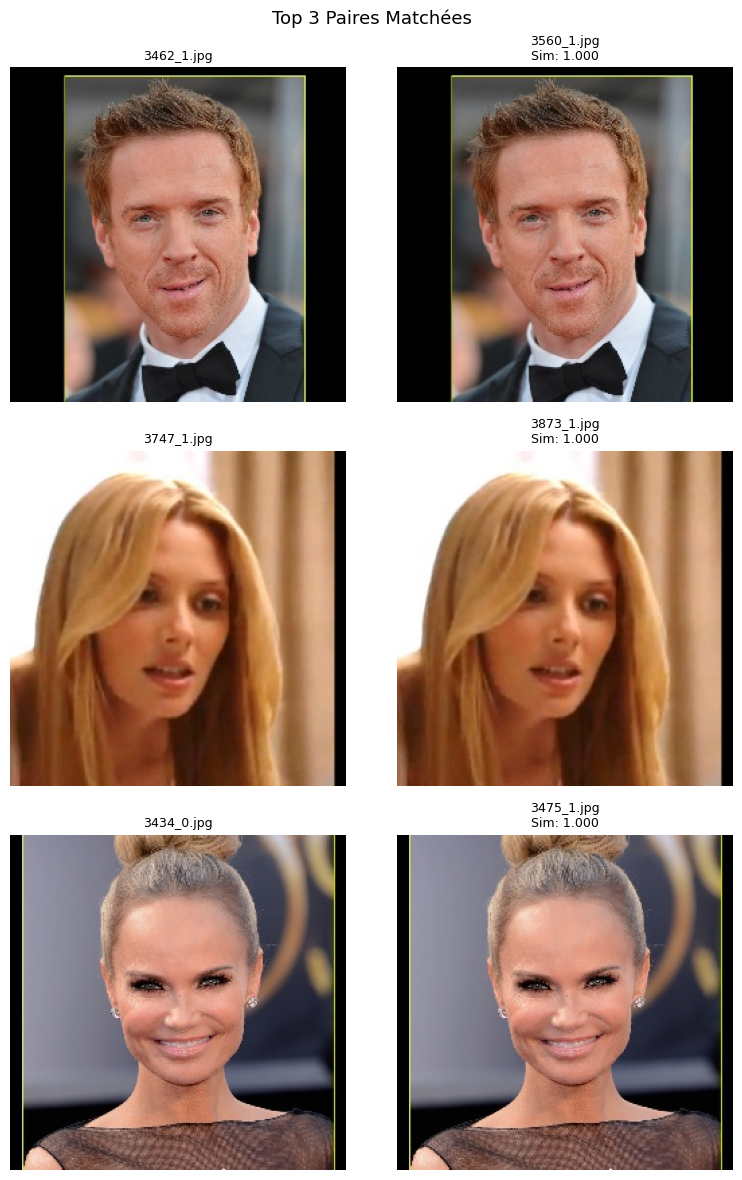

Visualisation sauvegardée : tache1_matches_visualization.png


In [ ]:
if len(matches_df) > 0:
    top_matches = matches_df.sort_values('similarity', ascending=False).head(3)
    fig, axes = plt.subplots(3, 2, figsize=(8, 12))

    for idx, (_, row) in enumerate(top_matches.iterrows()):
        for col, img_name in enumerate([row['image1'], row['image2']]):
            img = cv2.imread(str(TEST_PATH / img_name))
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                axes[idx, col].imshow(img)
            else:
                axes[idx, col].text(0.5, 0.5, 'Erreur', ha='center', va='center')
            label = img_name if col == 0 else f"{img_name}\nSim: {row['similarity']:.3f}"
            axes[idx, col].set_title(label, fontsize=9)
            axes[idx, col].axis('off')

    plt.suptitle('Top 3 Paires Matchées', fontsize=13)
    plt.tight_layout()
    plt.savefig('tache1_matches_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Visualisation sauvegardée : tache1_matches_visualization.png')
else:
    print('Aucune paire trouvée — essaie de baisser le seuil.')
